# IM2HEIGHT Dataset Variant Configuration

This notebook is designed to work with different variants of the DFC2023 dataset, including:

- **DFC2023Amini**: The original Amini dataset variant
- **DFC2023S**: Small dataset variant
- **DFC2023A**: Alternative dataset variant 
- Any other variant with the same file structure

## Usage Instructions

1. Set the `dataset_name` variable in the configuration cell to match your dataset variant
2. The notebook will automatically load the correct paths for:
   - Dataset location
   - Prediction files
   - Visualization outputs
3. All visualizations and metrics will be computed for the specified dataset

The dataset structure should follow the standard DFC2023 format with `/test/rgb/` and `/test/dsm/` directories.

# IM2HEIGHT Results Visualization

This notebook visualizes the results from the IM2HEIGHT model, comparing:
1. Input RGB images
2. Ground truth DSM (Digital Surface Model)
3. Predicted DSM from the model

We'll load samples from the test dataset and their corresponding predictions to evaluate the model's performance. This notebook supports different DFC2023 dataset variants (DFC2023Amini, DFC2023S, DFC2023A, etc.) with the same file structure.

In [1]:
# Import required libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
from PIL import Image
import torch
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error

# Add parent directory to path so we can import from the main project
sys.path.append('..')
from dfc2023_data import DFC2023Dataset

# Import the metrics module for comprehensive height evaluation
sys.path.append('../tools')
try:
    from metrics import compute_dsm_metrics
    metrics_module_loaded = True
except ImportError:
    print("Warning: Could not import metrics module. Using basic metrics only.")
    metrics_module_loaded = False

## Load Data

Let's set up the paths and load the test data. We'll load:
- RGB images from the test dataset
- Ground truth DSM from the test dataset
- Predicted DSM from the predictions folder

In [2]:
# Configure paths and dataset settings
# Change this variable to match the specific dataset variant you're using
dataset_name = "DFC2023S"  # Options: "DFC2023Amini", "DFC2023S", "DFC2023A", etc.

# Set up paths based on dataset name
dataset_path = f"/home/asfand/Ahmad/datasets/{dataset_name}"
predictions_path = f"/home/asfand/Ahmad/IM2HEIGHT/predictions/{dataset_name}"
output_dir = "/home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs"
os.makedirs(output_dir, exist_ok=True)  # Create output directory if it doesn't exist

# Load test dataset
test_dataset = DFC2023Dataset(dataset_path, 'test', 'rgb', 'dsm')

# Get list of prediction files
prediction_files = sorted([f for f in os.listdir(predictions_path) 
                         if f.endswith('_pred.npy') and os.path.isfile(os.path.join(predictions_path, f))])

print(f"Using dataset: {dataset_name}")
print(f"Found {len(prediction_files)} prediction files")
print(f"Test dataset contains {len(test_dataset)} samples")

Using dataset: DFC2023S
Found 177 prediction files
Test dataset contains 177 samples


In [3]:
# Analyze the dataset characteristics
def analyze_dataset(dataset_path, dataset_name):
    """Analyze the characteristics of the dataset and return summary information"""
    summary = {}
    summary['name'] = dataset_name
    
    # Check directories
    splits = ['train', 'valid', 'test']
    data_types = ['rgb', 'dsm', 'sar', 'sem']
    
    for split in splits:
        split_path = os.path.join(dataset_path, split)
        if not os.path.exists(split_path):
            continue
            
        summary[f'{split}_total'] = 0
        
        for dtype in data_types:
            type_path = os.path.join(split_path, dtype)
            if os.path.exists(type_path):
                files = [f for f in os.listdir(type_path) if os.path.isfile(os.path.join(type_path, f))]
                summary[f'{split}_{dtype}'] = len(files)
                if dtype == 'rgb' or dtype == 'dsm':  # Count these for total
                    summary[f'{split}_total'] = max(summary[f'{split}_total'], len(files))
    
    return summary

# Get dataset characteristics
dataset_info = analyze_dataset(dataset_path, dataset_name)

print(f"\nDataset Characteristics for {dataset_name}:")
print(f"Path: {dataset_path}")
for split in ['train', 'valid', 'test']:
    if f'{split}_total' in dataset_info:
        print(f"  {split.capitalize()} set: {dataset_info[f'{split}_total']} samples")
        for dtype in ['rgb', 'dsm', 'sar', 'sem']:
            if f'{split}_{dtype}' in dataset_info:
                print(f"    - {dtype.upper()}: {dataset_info[f'{split}_{dtype}']} files")

# Save dataset info for future comparison
os.makedirs(os.path.join(output_dir, 'dataset_info'), exist_ok=True)
dataset_info_file = os.path.join(output_dir, 'dataset_info', f"{dataset_name}_info.txt")

with open(dataset_info_file, 'w') as f:
    f.write(f"Dataset: {dataset_name}\n")
    f.write(f"Path: {dataset_path}\n")
    for k, v in dataset_info.items():
        if k != 'name':
            f.write(f"{k}: {v}\n")

print(f"\nDataset info saved to {dataset_info_file}")


Dataset Characteristics for DFC2023S:
Path: /home/asfand/Ahmad/datasets/DFC2023S
  Train set: 1419 samples
    - RGB: 1419 files
    - DSM: 1419 files
    - SAR: 1419 files
    - SEM: 1419 files
  Valid set: 177 samples
    - RGB: 177 files
    - DSM: 177 files
    - SAR: 177 files
    - SEM: 177 files
  Test set: 177 samples
    - RGB: 177 files
    - DSM: 177 files
    - SAR: 177 files
    - SEM: 177 files

Dataset info saved to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/dataset_info/DFC2023S_info.txt


## Visualization Helper Functions

Let's define helper functions to visualize the RGB images, ground truth DSMs, and predicted DSMs.

In [4]:
def normalize_array(arr):
    """Normalize array to 0-1 range for visualization"""
    min_val = np.min(arr)
    max_val = np.max(arr)
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

def resize_array(arr, target_shape):
    """Resize array to match target shape"""
    from skimage.transform import resize
    return resize(arr, target_shape, mode='constant', anti_aliasing=True)

# Define a simple logger for metrics calculation
class SimpleLogger:
    def __init__(self):
        pass
    
    def info(self, message):
        print(message)
    
    def warning(self, message):
        print(f"WARNING: {message}")

# Create logger instance
logger = SimpleLogger()

def visualize_sample(rgb_img, gt_dsm, pred_dsm, sample_name, save_fig=True):
    """
    Visualize a sample with RGB image, ground truth DSM, and predicted DSM.
    
    Args:
        rgb_img: RGB image tensor (C×H×W)
        gt_dsm: Ground truth DSM tensor (C×H×W)
        pred_dsm: Predicted DSM array (H×W)
        sample_name: Name of the sample for the figure title
        save_fig: Whether to save the figure
    """
    # Convert tensors to numpy and prepare for visualization
    rgb_np = rgb_img.permute(1, 2, 0).numpy()  # Convert to H×W×C for display
    
    # If RGB values are outside [0, 1], normalize them
    if rgb_np.max() > 1.0 or rgb_np.min() < 0.0:
        rgb_np = normalize_array(rgb_np)
    
    # Extract channel 0 from ground truth DSM if it's multi-channel
    if isinstance(gt_dsm, torch.Tensor):
        gt_dsm_np = gt_dsm[0].numpy() if gt_dsm.dim() > 2 else gt_dsm.numpy()
    else:
        gt_dsm_np = gt_dsm[0] if gt_dsm.ndim > 2 else gt_dsm
    
    # Extract the height values from the prediction (might need adjustment based on exact format)
    if pred_dsm.ndim > 2:
        pred_dsm_np = pred_dsm[0] if pred_dsm.shape[0] == 1 else pred_dsm
    else:
        pred_dsm_np = pred_dsm

    # Print the shapes for debugging
    print(f"RGB shape: {rgb_np.shape}")
    print(f"Ground truth DSM shape: {gt_dsm_np.shape}")
    print(f"Predicted DSM shape: {pred_dsm_np.shape}")
    
    # Ensure ground truth and prediction have the same shape for metrics calculation
    if gt_dsm_np.shape != pred_dsm_np.shape:
        print(f"Resizing prediction to match ground truth shape: {gt_dsm_np.shape}")
        pred_dsm_np = resize_array(pred_dsm_np, gt_dsm_np.shape)
        print(f"After resizing, predicted DSM shape: {pred_dsm_np.shape}")

    # Calculate comprehensive error metrics if metrics module is available
    metrics_str = ""
    
    if metrics_module_loaded:
        # Initialize running totals (will be overwritten)
        total_delta1, total_delta2, total_delta3 = 0, 0, 0
        total_mse, total_mae, total_rmse = 0, 0, 0
        
        # Compute metrics using the metrics module
        total_delta1, total_delta2, total_delta3, total_mse, total_mae, total_rmse, _, _ = compute_dsm_metrics(
            False, logger, total_delta1, total_delta2, total_delta3, 
            total_mse, total_mae, total_rmse, gt_dsm_np, pred_dsm_np
        )
        
        # Calculate SSIM separately
        ssim_val = ssim(gt_dsm_np, pred_dsm_np, data_range=pred_dsm_np.max() - pred_dsm_np.min())
        
        # Create comprehensive metrics string
        metrics_str = f"MSE: {total_mse:.2f}, RMSE: {total_rmse:.2f}, MAE: {total_mae:.2f}, "\
                     f"SSIM: {ssim_val:.2f}, "\
                     f"Delta1: {total_delta1:.2f}, Delta2: {total_delta2:.2f}, Delta3: {total_delta3:.2f}"
        
        # Store metrics for return
        metrics = {
            'mse': total_mse,
            'rmse': total_rmse,
            'mae': total_mae,
            'ssim': ssim_val,
            'delta1': total_delta1,
            'delta2': total_delta2,
            'delta3': total_delta3,
            'min_error': np.min(gt_dsm_np - pred_dsm_np),
            'max_error': np.max(gt_dsm_np - pred_dsm_np),
            'mean_error': np.mean(gt_dsm_np - pred_dsm_np)
        }
    else:
        # Fallback to basic metrics if metrics module isn't available
        mse = mean_squared_error(gt_dsm_np, pred_dsm_np)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(gt_dsm_np - pred_dsm_np))
        ssim_val = ssim(gt_dsm_np, pred_dsm_np, data_range=pred_dsm_np.max() - pred_dsm_np.min())
        
        metrics_str = f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, SSIM: {ssim_val:.2f}"
        
        # Store basic metrics for return
        metrics = {
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'ssim': ssim_val,
            'min_error': np.min(gt_dsm_np - pred_dsm_np),
            'max_error': np.max(gt_dsm_np - pred_dsm_np),
            'mean_error': np.mean(gt_dsm_np - pred_dsm_np)
        }
    
    # Calculate error map
    error_map = gt_dsm_np - pred_dsm_np
    
    # Create colormap for height maps
    elevation_cmap = cm.terrain
    error_cmap = cm.RdBu_r
    
    # Create figure with 2x2 subplots
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    # RGB image
    axs[0, 0].imshow(rgb_np)
    axs[0, 0].set_title('RGB Input Image')
    axs[0, 0].axis('off')
    
    # Ground truth DSM
    gt_img = axs[0, 1].imshow(gt_dsm_np, cmap=elevation_cmap)
    axs[0, 1].set_title('Ground Truth DSM')
    axs[0, 1].axis('off')
    plt.colorbar(gt_img, ax=axs[0, 1], fraction=0.046, pad=0.04)
    
    # Predicted DSM
    pred_img = axs[1, 0].imshow(pred_dsm_np, cmap=elevation_cmap)
    axs[1, 0].set_title(f'Predicted DSM')
    axs[1, 0].axis('off')
    plt.colorbar(pred_img, ax=axs[1, 0], fraction=0.046, pad=0.04)
    
    # Error map
    error_img = axs[1, 1].imshow(error_map, cmap=error_cmap)
    axs[1, 1].set_title(f'Error Map\n{metrics_str}')
    axs[1, 1].axis('off')
    plt.colorbar(error_img, ax=axs[1, 1], fraction=0.046, pad=0.04)
    
    # Overall title
    plt.suptitle(f'Sample: {sample_name}', fontsize=16)
    plt.tight_layout()
    
    # Save figure if requested
    if save_fig:
        output_path = os.path.join(output_dir, f"{sample_name}_comparison.png")
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"Saved visualization to {output_path}")
    
    return fig, metrics

## Visualization of Test Samples

Now let's visualize a few samples from the test dataset along with their predictions.

In [5]:
# Match prediction files with test samples
results = []

# Collect matching samples and predictions
for i, (img_tensor, label_tensor) in enumerate(test_dataset):
    # Get the sample basename (e.g., "SV_Berlin_52.5054_13.4804")
    input_path = test_dataset.input_files[i]
    sample_basename = os.path.splitext(os.path.basename(input_path))[0]
    
    # Find the corresponding prediction file
    pred_filename = f"{sample_basename}_pred.npy"
    pred_path = os.path.join(predictions_path, pred_filename)
    
    if os.path.exists(pred_path):
        pred_dsm = np.load(pred_path)
        results.append({
            'sample_name': sample_basename,
            'rgb_img': img_tensor,
            'gt_dsm': label_tensor,
            'pred_dsm': pred_dsm
        })
    else:
        print(f"Warning: No prediction found for {sample_basename}")

print(f"Found {len(results)} matching samples with predictions")

Found 177 matching samples with predictions


Creating sample elevation data using numpy...
Elevation statistics:
  Min height: -0.48
  Max height: 10.14
  Mean height: 2.88
  Standard deviation: 2.61
  Max slope: 0.98


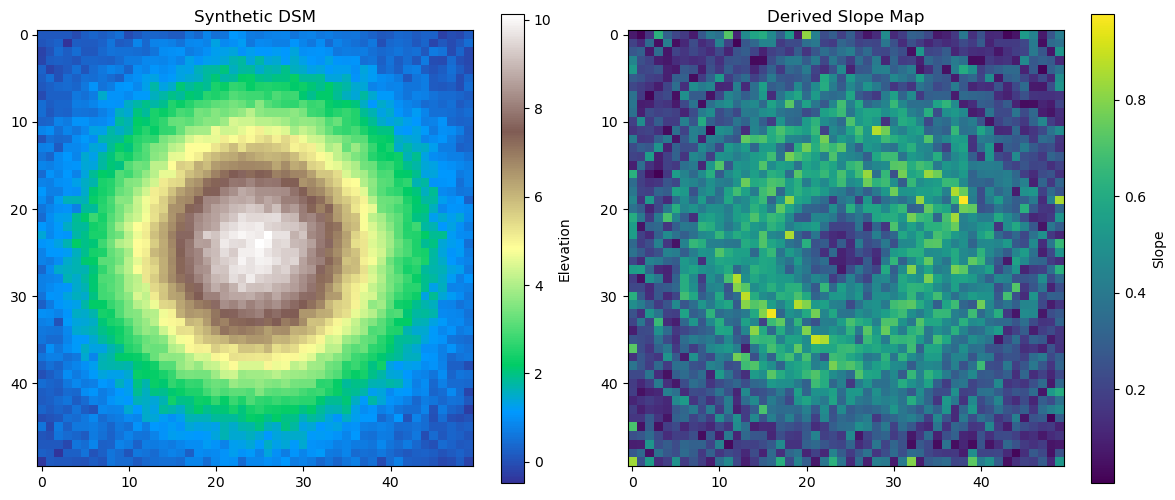


Areas with elevation > 5.0m: 21.1% of the terrain


In [6]:
# Cell to test and demonstrate numpy functionality with DSM data

# Basic array operations with sample data
print("Creating sample elevation data using numpy...")
sample_size = (50, 50)
# Create synthetic terrain with a central mountain
x, y = np.meshgrid(np.linspace(-5, 5, sample_size[0]), np.linspace(-5, 5, sample_size[1]))
synthetic_dsm = 10 * np.exp(-(x**2 + y**2) / 10)  # Gaussian hill

# Add some random noise to simulate real-world terrain variations
noisy_dsm = synthetic_dsm + np.random.normal(0, 0.2, sample_size)

# Calculate basic statistics
print(f"Elevation statistics:")
print(f"  Min height: {np.min(noisy_dsm):.2f}")
print(f"  Max height: {np.max(noisy_dsm):.2f}")
print(f"  Mean height: {np.mean(noisy_dsm):.2f}")
print(f"  Standard deviation: {np.std(noisy_dsm):.2f}")

# Calculate slope using numpy's gradient function
dy, dx = np.gradient(noisy_dsm)
slope = np.sqrt(dx**2 + dy**2)
print(f"  Max slope: {np.max(slope):.2f}")

# Visualize the synthetic terrain
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy_dsm, cmap=cm.terrain)
plt.colorbar(label='Elevation')
plt.title('Synthetic DSM')

plt.subplot(1, 2, 2)
plt.imshow(slope, cmap='viridis')
plt.colorbar(label='Slope')
plt.title('Derived Slope Map')

plt.tight_layout()
plt.show()

# Demonstrate masking - identifying areas above a certain elevation
elevation_threshold = 5.0
high_areas = np.ma.masked_where(noisy_dsm < elevation_threshold, noisy_dsm)
percent_high = (np.sum(noisy_dsm >= elevation_threshold) / noisy_dsm.size) * 100

print(f"\nAreas with elevation > {elevation_threshold}m: {percent_high:.1f}% of the terrain")

## Display Sample Results

Let's visualize the first few test samples.

RGB shape: (512, 512, 3)
Ground truth DSM shape: (512, 512)
Predicted DSM shape: (512, 512)


/home/asfand/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/asfand/.local/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved visualization to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8653_-47.9279_comparison.png


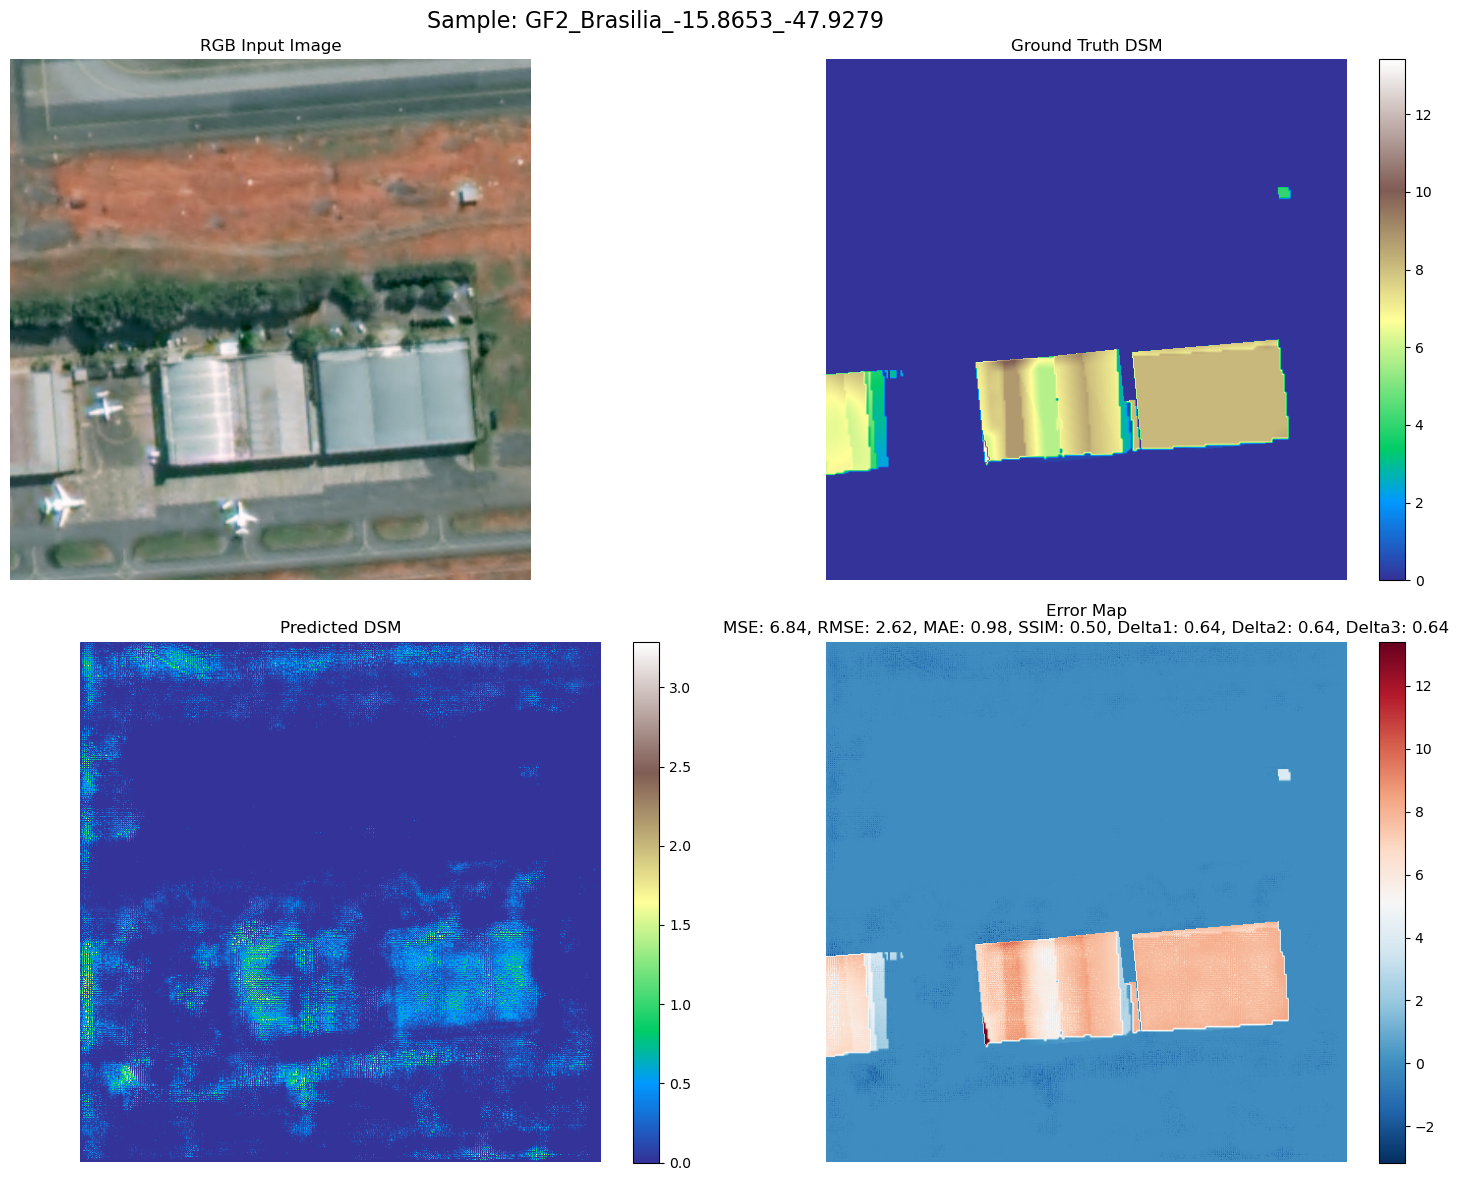

RGB shape: (512, 512, 3)
Ground truth DSM shape: (512, 512)
Predicted DSM shape: (512, 512)
Saved visualization to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8653_-47.9293_comparison.png


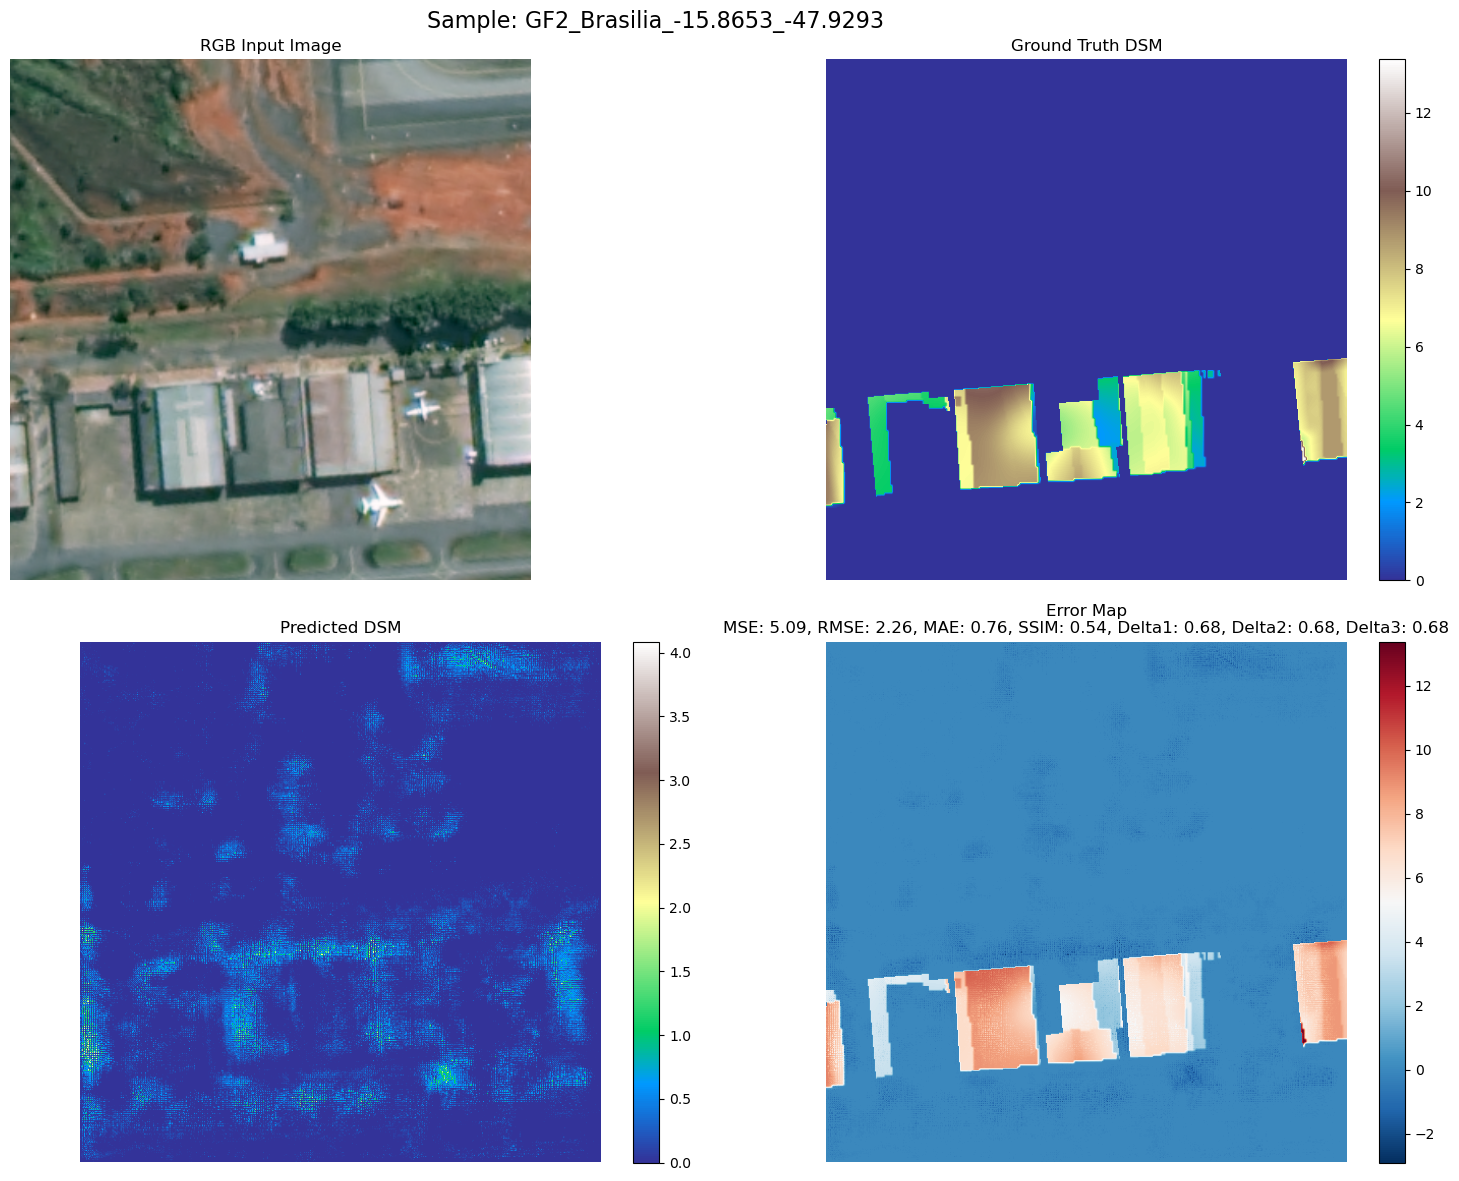

RGB shape: (512, 512, 3)
Ground truth DSM shape: (512, 512)
Predicted DSM shape: (512, 512)
Saved visualization to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8667_-47.9277_comparison.png


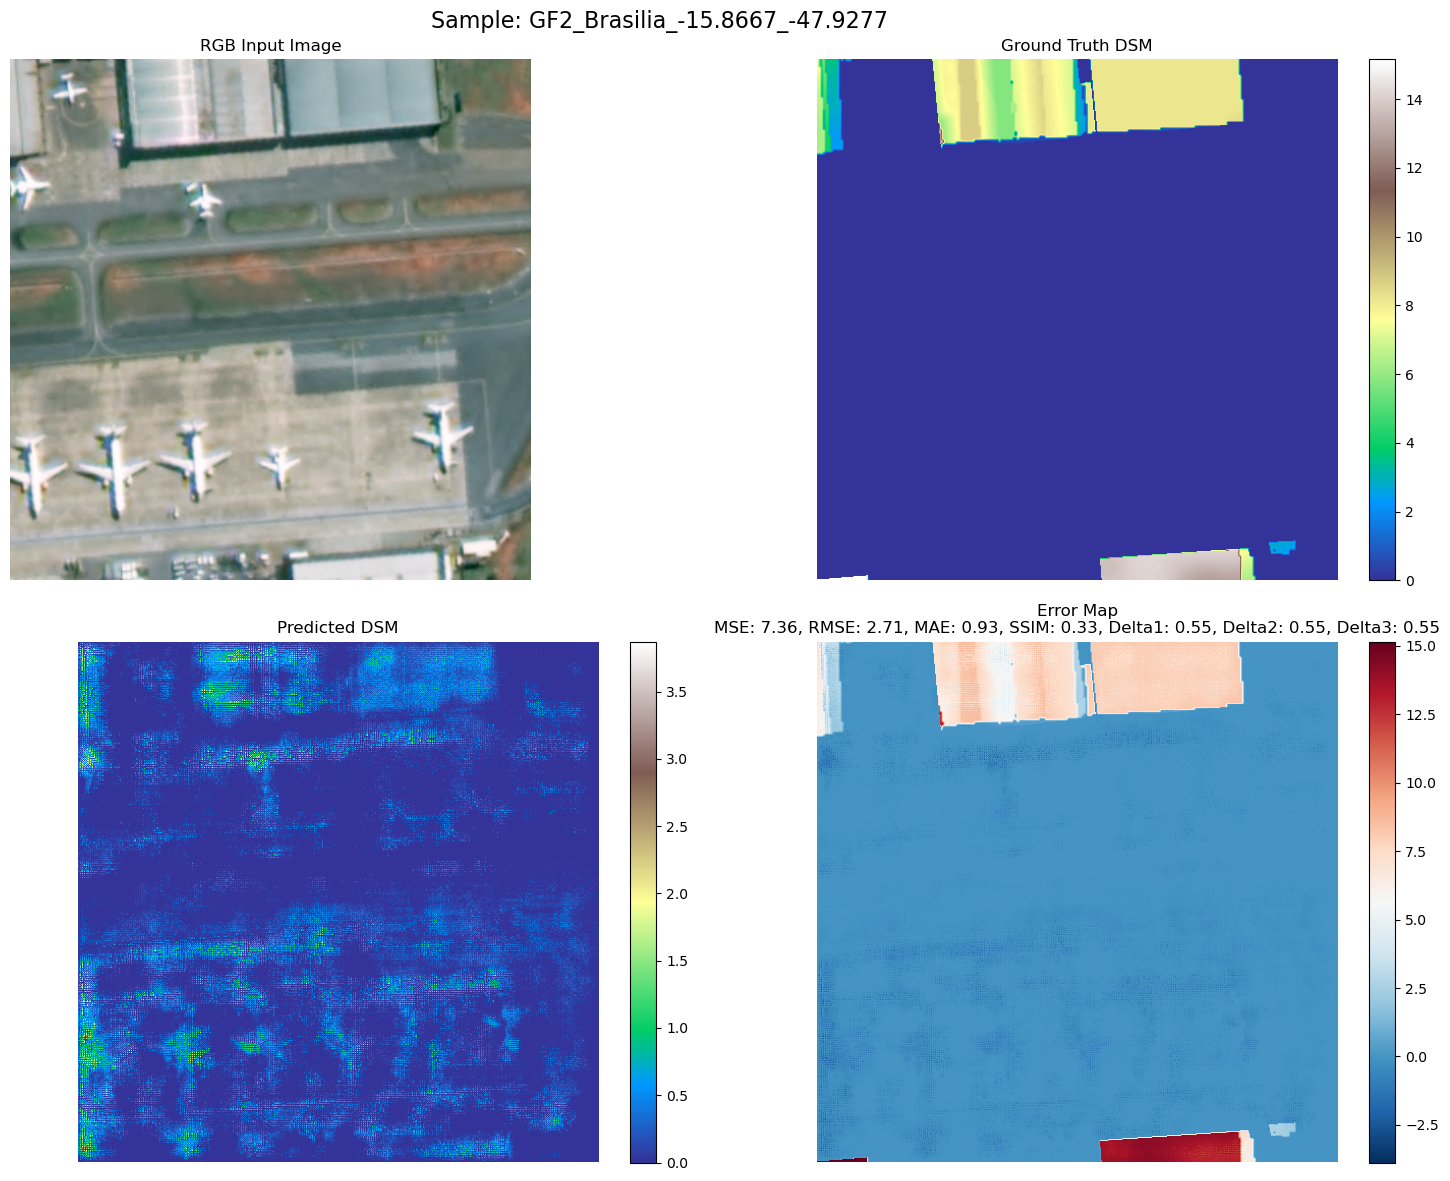

RGB shape: (512, 512, 3)
Ground truth DSM shape: (512, 512)
Predicted DSM shape: (512, 512)
Saved visualization to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8667_-47.9308_comparison.png


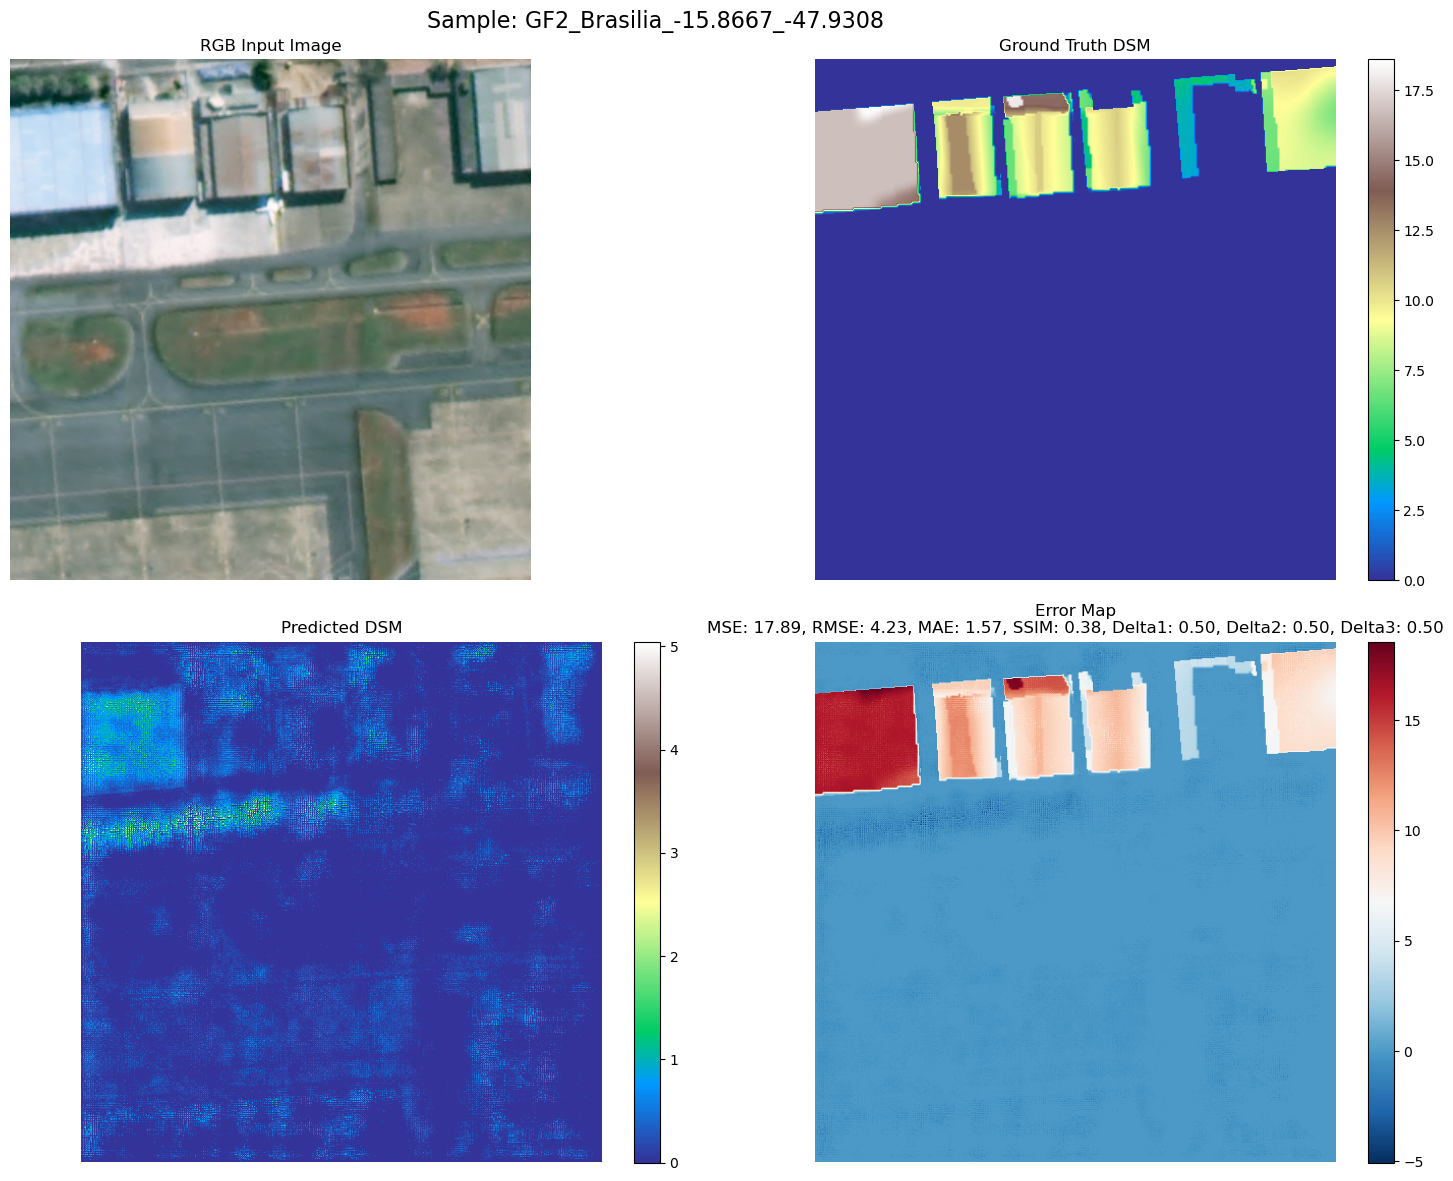

In [7]:
# Visualize the first 4 samples or all if there are fewer
num_samples_to_show = min(4, len(results))
all_metrics = []

for i in range(num_samples_to_show):
    result = results[i]
    fig, metrics = visualize_sample(
        result['rgb_img'], 
        result['gt_dsm'], 
        result['pred_dsm'], 
        result['sample_name']
    )
    
    # Add sample name to metrics
    metrics['sample_name'] = result['sample_name']
    all_metrics.append(metrics)
    
    plt.show()
    plt.close(fig)  # Close to free memory

## Statistical Analysis of Results

Let's calculate overall metrics across all test samples to evaluate the model's performance on the {dataset_name} dataset.

In [8]:
# Calculate metrics for all samples
metrics = []

for result in results:
    # Extract ground truth and prediction
    gt = result['gt_dsm'][0].numpy() if result['gt_dsm'].dim() > 2 else result['gt_dsm'].numpy()
    pred = result['pred_dsm'][0] if result['pred_dsm'].ndim > 2 else result['pred_dsm']
    
    # Ensure ground truth and prediction have the same shape
    if gt.shape != pred.shape:
        print(f"Sample {result['sample_name']}: Resizing prediction from {pred.shape} to match ground truth shape {gt.shape}")
        pred = resize_array(pred, gt.shape)
    
    # Calculate metrics using the comprehensive metrics function if available
    if metrics_module_loaded:
        # Initialize running totals (will be overwritten)
        total_delta1, total_delta2, total_delta3 = 0, 0, 0
        total_mse, total_mae, total_rmse = 0, 0, 0
        
        try:
            # Compute metrics using the metrics module
            total_delta1, total_delta2, total_delta3, total_mse, total_mae, total_rmse, _, _ = compute_dsm_metrics(
                False, logger, total_delta1, total_delta2, total_delta3, 
                total_mse, total_mae, total_rmse, gt, pred
            )
            
            # Calculate SSIM separately
            ssim_val = ssim(gt, pred, data_range=pred.max() - pred.min())
            
            metrics.append({
                'sample_name': result['sample_name'],
                'mse': total_mse,
                'rmse': total_rmse,
                'mae': total_mae,
                'ssim': ssim_val,
                'delta1': total_delta1,
                'delta2': total_delta2,
                'delta3': total_delta3,
                'min_error': (gt - pred).min(),
                'max_error': (gt - pred).max(),
                'mean_error': np.mean(gt - pred)
            })
        except Exception as e:
            print(f"Error calculating metrics for sample {result['sample_name']}: {e}")
            # Add a row with NaN values
            metrics.append({
                'sample_name': result['sample_name'],
                'mse': float('nan'),
                'rmse': float('nan'),
                'mae': float('nan'),
                'ssim': float('nan'),
                'delta1': float('nan'),
                'delta2': float('nan'),
                'delta3': float('nan'),
                'min_error': float('nan'),
                'max_error': float('nan'),
                'mean_error': float('nan')
            })
    else:
        # Fall back to basic metrics
        try:
            mse = mean_squared_error(gt, pred)
            rmse = np.sqrt(mse)
            mae = np.mean(np.abs(gt - pred))
            ssim_val = ssim(gt, pred, data_range=pred.max()-pred.min())
            
            metrics.append({
                'sample_name': result['sample_name'],
                'mse': mse,
                'rmse': rmse,
                'mae': mae,
                'ssim': ssim_val,
                'min_error': (gt - pred).min(),
                'max_error': (gt - pred).max(),
                'mean_error': np.mean(gt - pred)
            })
        except Exception as e:
            print(f"Error calculating metrics for sample {result['sample_name']}: {e}")
            # Add a row with NaN values
            metrics.append({
                'sample_name': result['sample_name'],
                'mse': float('nan'),
                'rmse': float('nan'),
                'mae': float('nan'),
                'ssim': float('nan'),
                'min_error': float('nan'),
                'max_error': float('nan'),
                'mean_error': float('nan')
            })

# Display metrics as a table
import pandas as pd
metrics_df = pd.DataFrame(metrics)
print(f"Summary statistics for {dataset_name}:")
print(metrics_df.describe())

# Show individual sample metrics
metrics_df

Summary statistics for DFC2023S:
              mse        rmse         mae        ssim      delta1      delta2  \
count  177.000000  177.000000  177.000000  177.000000  177.000000  177.000000   
mean    83.854837    7.280809    3.483376    0.566094    0.681480    0.681664   
std    135.202171    5.569552    3.364991    0.157987    0.123118    0.123090   
min      0.005568    0.074620    0.006660    0.177315    0.278393    0.278931   
25%      8.241308    2.870768    1.264931    0.458701    0.612087    0.612301   
50%     31.911772    5.649051    2.250725    0.581446    0.692818    0.692879   
75%     93.740746    9.681980    4.507648    0.686298    0.770256    0.770256   
max    824.063660   28.706509   17.654236    0.927186    0.980820    0.980820   

           delta3   min_error   max_error  mean_error  
count  177.000000  177.000000  177.000000  177.000000  
mean     0.681872   -2.739439   29.352203    3.449549  
std      0.123032    0.977862   20.958879    3.369182  
min      0.28

,sample_name,mse,rmse,mae,ssim,delta1,delta2,delta3,min_error,max_error,mean_error
0,GF2_Brasilia_-15.8653_-47.9279,6.844372,2.616175,0.981972,0.495507,0.638760,0.638824,0.638905,-3.150376,13.412226,0.887184
1,GF2_Brasilia_-15.8653_-47.9293,5.092203,2.256591,0.760363,0.542554,0.678684,0.678814,0.678902,-2.897924,13.377609,0.663700
2,GF2_Brasilia_-15.8667_-47.9277,7.364347,2.713733,0.926034,0.330830,0.545803,0.545940,0.546139,-3.873007,15.159730,0.745886
3,GF2_Brasilia_-15.8667_-47.9308,17.888491,4.229479,1.568040,0.382929,0.500515,0.500549,0.500629,-5.046580,18.559837,1.403014
4,GF2_Brasilia_-15.8680_-47.9366,5.140557,2.267280,0.649259,0.623852,0.681240,0.681290,0.681389,-2.744813,11.854524,0.557114
...,...,...,...,...,...,...,...,...,...,...,...
172,SV_SaoLuis_-2.5344_-44.2939,12.443063,3.527472,1.543608,0.595111,0.719841,0.719898,0.719967,-3.040487,21.826834,1.525834
173,SV_SaoLuis_-2.5355_-44.2939,16.543983,4.067430,2.271358,0.412654,0.565891,0.565968,0.566048,-2.949319,21.825592,2.256314
174,SV_SaoLuis_-2.5355_-44.2988,33.409813,5.780122,3.940578,0.304384,0.441696,0.441727,0.441750,-1.669805,22.543356,3.938157
175,SV_Sydney_-33.8621_151.1943,29.652857,5.445444,1.909473,0.636899,0.651897,0.651932,0.651962,-3.957170,20.400002,1.870978


In [9]:
# Save metrics to CSV for dataset variant comparison
csv_output_path = os.path.join(output_dir, f"{dataset_name}_metrics_summary.csv")
metrics_df.to_csv(csv_output_path, index=False)

# Save summary statistics to a separate CSV
summary_df = metrics_df.describe()
summary_csv_path = os.path.join(output_dir, f"{dataset_name}_metrics_summary_stats.csv")
summary_df.to_csv(summary_csv_path)

print(f"Saved metrics to {csv_output_path}")
print(f"Saved summary statistics to {summary_csv_path}")

Saved metrics to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/DFC2023S_metrics_summary.csv
Saved summary statistics to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/DFC2023S_metrics_summary_stats.csv


## Understanding Height Regression Metrics

Let's explain the key metrics used to evaluate the height prediction model:

1. **RMSE (Root Mean Squared Error)**:
   - The square root of the average squared differences between predicted and ground truth heights
   - More sensitive to large errors due to squaring
   - Lower values are better (closer to 0 is perfect prediction)
   - Used as a standard metric in height estimation tasks

2. **MAE (Mean Absolute Error)**:
   - The average absolute differences between predicted and ground truth heights
   - Less sensitive to outliers than RMSE
   - Easier to interpret as it's in the same units as the height values (e.g., meters)
   - Lower values are better

3. **Delta Metrics (δ1, δ2, δ3)**:
   - Fraction of pixels where the ratio of predicted and ground truth heights (or vice versa) is less than thresholds:
     - δ1: ratio < 1.25
     - δ2: ratio < 1.25²
     - δ3: ratio < 1.25³
   - Higher values are better (closer to 1 means more predictions are within the threshold)
   - Commonly used in depth estimation tasks

4. **MSE (Mean Squared Error)**:
   - Average of squared differences between predicted and ground truth heights
   - Unit is squared height units (e.g., squared meters)
   - Used as a training loss but less interpretable than RMSE or MAE

5. **SSIM (Structural Similarity Index)**:
   - Measures the perceptual similarity between images
   - Range from -1 to 1 (1 means identical images)
   - Captures structural information beyond pixel-level differences

Let's create a visualization to help interpret these metrics for the current model.

In [10]:
# Create a visual representation of metrics importance and interpretation
def plot_metrics_interpretation(metrics_df):
    """Plot a visual interpretation of key metrics from the results"""
    
    # Calculate means for key metrics
    mean_metrics = metrics_df.mean()
    
    # Create a figure with three subplots
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    # Error metrics bar chart (lower is better)
    error_metrics = ['mae', 'rmse', 'mse']
    error_values = [mean_metrics['mae'], mean_metrics['rmse'], mean_metrics['mse']/10]  # Scale MSE down for visibility
    error_colors = ['green', 'orange', 'red']
    
    axs[0, 0].bar(error_metrics, error_values, color=error_colors)
    axs[0, 0].set_title('Error Metrics (lower is better)')
    axs[0, 0].set_ylabel('Error magnitude')
    if 'mse' in mean_metrics:
        axs[0, 0].annotate(f"MSE shown at 1/10 scale\nActual: {mean_metrics['mse']:.2f}", 
                        xy=(2, error_values[2] + 0.2), ha='center')
    
    # Delta metrics bar chart (higher is better)
    if 'delta1' in mean_metrics:
        delta_metrics = ['delta1', 'delta2', 'delta3']
        delta_values = [mean_metrics['delta1'], mean_metrics['delta2'], mean_metrics['delta3']]
        delta_colors = ['lightblue', 'blue', 'darkblue']
        
        axs[0, 1].bar(delta_metrics, delta_values, color=delta_colors)
        axs[0, 1].set_title('Delta Metrics (higher is better)')
        axs[0, 1].set_ylabel('Fraction of pixels within threshold')
        axs[0, 1].set_ylim(0, 1.0)
        
        # Add threshold explanations
        thresholds = ['ratio < 1.25', 'ratio < 1.25²', 'ratio < 1.25³']
        for i, (metric, threshold) in enumerate(zip(delta_metrics, thresholds)):
            axs[0, 1].annotate(threshold, xy=(i, delta_values[i] + 0.05), ha='center')
    
    # Error distribution histogram
    if not metrics_df['mean_error'].isna().all():
        axs[1, 0].hist(metrics_df['mean_error'], bins=10, color='purple', alpha=0.7)
        axs[1, 0].set_title('Mean Error Distribution')
        axs[1, 0].set_xlabel('Mean Error')
        axs[1, 0].set_ylabel('Number of Samples')
        axs[1, 0].axvline(x=0, color='black', linestyle='--')  # Perfect prediction line
    
    # SSIM plot
    if 'ssim' in mean_metrics:
        # Simple gauge-like visualization for SSIM
        ssim_value = mean_metrics['ssim']
        
        # Create a gauge-like graphic
        ax_ssim = axs[1, 1]
        ax_ssim.set_xlim(-1.2, 1.2)
        ax_ssim.set_ylim(-0.6, 0.6)
        ax_ssim.axis('off')
        
        # Draw the gauge background
        ax_ssim.add_patch(plt.Rectangle((-1, -0.2), 2, 0.4, color='lightgray', alpha=0.5))
        ax_ssim.add_patch(plt.Rectangle((-1, -0.2), 0.67, 0.4, color='red', alpha=0.5))
        ax_ssim.add_patch(plt.Rectangle((-0.33, -0.2), 0.66, 0.4, color='yellow', alpha=0.5))
        ax_ssim.add_patch(plt.Rectangle((0.33, -0.2), 0.67, 0.4, color='green', alpha=0.5))
        
        # Add marker for current SSIM value
        marker_x = ssim_value
        ax_ssim.arrow(0, -0.4, marker_x, 0, width=0.05, head_width=0.15, 
                     head_length=0.1, fc='blue', ec='blue')
        ax_ssim.text(marker_x, -0.5, f"SSIM: {ssim_value:.3f}", ha='center', fontsize=12)
        
        # Add labels
        ax_ssim.text(-0.8, 0.1, "Poor similarity", ha='center')
        ax_ssim.text(0, 0.1, "Moderate similarity", ha='center')
        ax_ssim.text(0.8, 0.1, "High similarity", ha='center')
        ax_ssim.text(0, 0.4, "Structural Similarity Index (SSIM)", ha='center', fontsize=14)
    
    plt.tight_layout()
    plt.suptitle(f"Height Prediction Metrics Interpretation for {dataset_name}", fontsize=16, y=1.02)
    
    # Save the interpretation figure
    interpretation_path = os.path.join(output_dir, f"{dataset_name}_metrics_interpretation.png")
    plt.savefig(interpretation_path, dpi=200, bbox_inches='tight')
    print(f"Saved metrics interpretation to {interpretation_path}")
    
    return fig

# Plot metrics interpretation if we have data
try:
    fig = plot_metrics_interpretation(metrics_df)
    plt.show()
    plt.close(fig)
except Exception as e:
    print(f"Could not create metrics interpretation visualization: {e}")

Could not create metrics interpretation visualization: Could not convert ['GF2_Brasilia_-15.8653_-47.9279GF2_Brasilia_-15.8653_-47.9293GF2_Brasilia_-15.8667_-47.9277GF2_Brasilia_-15.8667_-47.9308GF2_Brasilia_-15.8680_-47.9366GF2_Brasilia_-15.8694_-47.9367GF2_Brasilia_-15.8695_-47.9294GF2_Brasilia_-15.8695_-47.9308GF2_Brasilia_-15.8707_-47.9279SV_Barcelona_41.3773_2.1463SV_Barcelona_41.3774_2.1583SV_Barcelona_41.3774_2.1599SV_Barcelona_41.3809_2.1444SV_Barcelona_41.3877_2.1518SV_Barcelona_41.3925_2.1498SV_Barcelona_41.3953_2.1498SV_Berlin_52.4902_13.5058SV_Berlin_52.4904_13.4979SV_Berlin_52.4917_13.4443SV_Berlin_52.4932_13.4955SV_Berlin_52.4934_13.5089SV_Berlin_52.4939_13.4341SV_Berlin_52.4939_13.4387SV_Berlin_52.4966_13.5018SV_Berlin_52.4981_13.5078SV_Berlin_52.4994_13.4999SV_Berlin_52.4995_13.5077SV_Berlin_52.4995_13.5087SV_Berlin_52.5007_13.4930SV_Berlin_52.5009_13.5087SV_Berlin_52.5022_13.4975SV_Berlin_52.5039_13.4292SV_Berlin_52.5053_13.4781SV_Berlin_52.5054_13.4360SV_Berlin_52.505

## Generate Height Profiles

Let's generate height profiles (cross-sections) to compare ground truth and predicted heights along a line through the center of the image.

In [11]:
def plot_height_profile(gt_dsm, pred_dsm, sample_name, direction='horizontal', save_fig=True):
    """
    Plot height profile along a line through the center of the image
    
    Args:
        gt_dsm: Ground truth DSM tensor or array
        pred_dsm: Predicted DSM array
        sample_name: Name of the sample for the figure title
        direction: 'horizontal' or 'vertical'
        save_fig: Whether to save the figure
    """
    # Extract channel 0 from ground truth DSM if it's multi-channel
    if isinstance(gt_dsm, torch.Tensor):
        gt_dsm_np = gt_dsm[0].numpy() if gt_dsm.dim() > 2 else gt_dsm.numpy()
    else:
        gt_dsm_np = gt_dsm[0] if gt_dsm.ndim > 2 else gt_dsm
    
    # Extract the height values from the prediction
    if pred_dsm.ndim > 2:
        pred_dsm_np = pred_dsm[0] if pred_dsm.shape[0] == 1 else pred_dsm
    else:
        pred_dsm_np = pred_dsm
        
    # Ensure ground truth and prediction have the same shape
    if gt_dsm_np.shape != pred_dsm_np.shape:
        print(f"Resizing prediction to match ground truth shape: {gt_dsm_np.shape}")
        pred_dsm_np = resize_array(pred_dsm_np, gt_dsm_np.shape)
        print(f"After resizing, predicted DSM shape: {pred_dsm_np.shape}")
    
    # Get the height and width
    h, w = gt_dsm_np.shape
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if direction == 'horizontal':
        # Get the middle row
        row_idx = h // 2
        gt_profile = gt_dsm_np[row_idx, :]
        pred_profile = pred_dsm_np[row_idx, :]
        x_vals = np.arange(w)
        x_label = 'Column'
        title_direction = 'Horizontal'
    else:  # vertical
        # Get the middle column
        col_idx = w // 2
        gt_profile = gt_dsm_np[:, col_idx]
        pred_profile = pred_dsm_np[:, col_idx]
        x_vals = np.arange(h)
        x_label = 'Row'
        title_direction = 'Vertical'
    
    # Plot the profiles
    ax.plot(x_vals, gt_profile, 'b-', label='Ground Truth', linewidth=2)
    ax.plot(x_vals, pred_profile, 'r--', label='Prediction', linewidth=2)
    ax.fill_between(x_vals, gt_profile, pred_profile, color='gray', alpha=0.3)
    
    # Calculate profile metrics
    profile_mae = np.mean(np.abs(gt_profile - pred_profile))
    profile_rmse = np.sqrt(np.mean((gt_profile - pred_profile)**2))
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel('Height')
    ax.set_title(f'{title_direction} Height Profile for {sample_name}\nMAE: {profile_mae:.2f}, RMSE: {profile_rmse:.2f}')
    ax.legend()
    ax.grid(True)
    
    # Save figure if requested
    if save_fig:
        output_path = os.path.join(output_dir, f"{sample_name}_{direction}_profile.png")
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"Saved height profile to {output_path}")
    
    return fig

Saved height profile to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8653_-47.9279_horizontal_profile.png


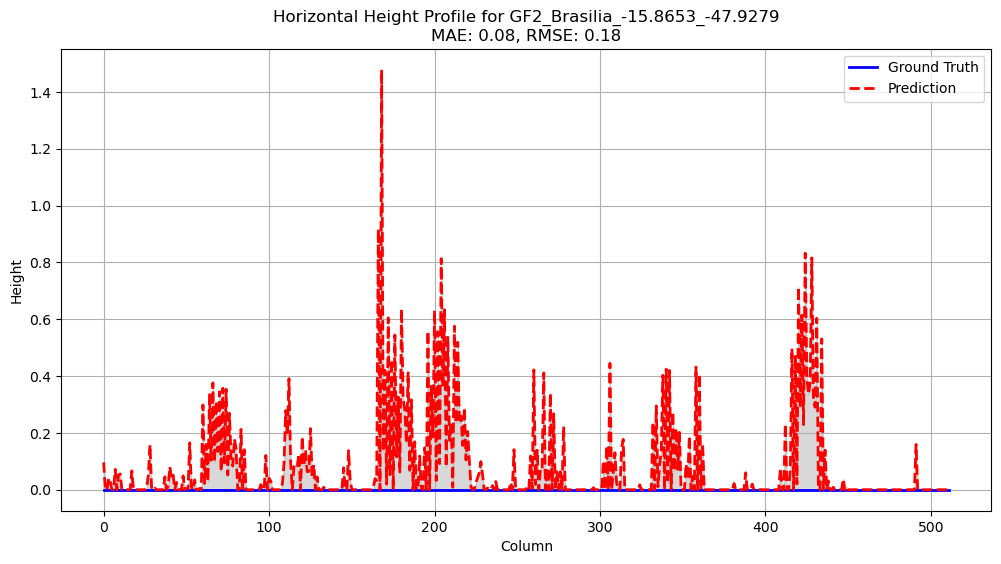

Saved height profile to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8653_-47.9279_vertical_profile.png


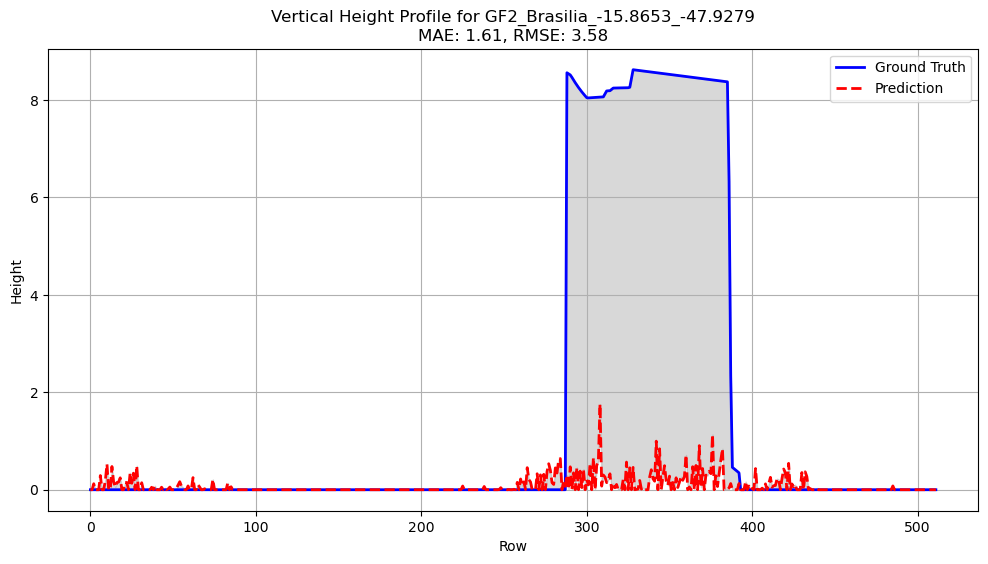

Saved height profile to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8653_-47.9293_horizontal_profile.png


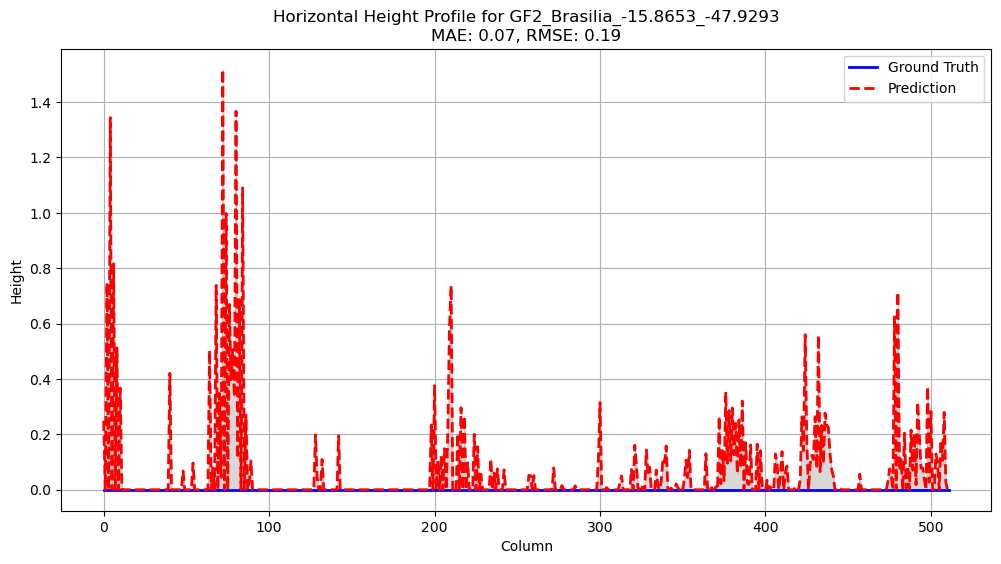

Saved height profile to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8653_-47.9293_vertical_profile.png


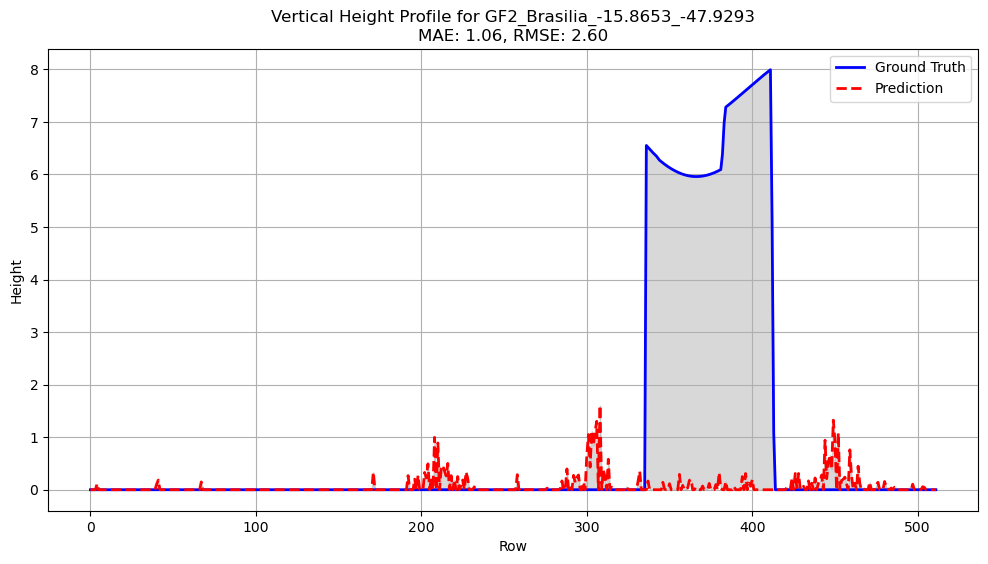

In [12]:
# Plot height profiles for the first 2 samples
for i in range(min(2, len(results))):
    result = results[i]
    
    # Horizontal profile
    fig_h = plot_height_profile(
        result['gt_dsm'],
        result['pred_dsm'],
        result['sample_name'],
        direction='horizontal'
    )
    plt.show()
    plt.close(fig_h)
    
    # Vertical profile
    fig_v = plot_height_profile(
        result['gt_dsm'],
        result['pred_dsm'],
        result['sample_name'],
        direction='vertical'
    )
    plt.show()
    plt.close(fig_v)

## 3D Surface Visualization

Let's create 3D surface plots to better visualize the height predictions.

In [13]:
def plot_3d_surface(gt_dsm, pred_dsm, sample_name, save_fig=True):
    """
    Create 3D surface plots of the ground truth and predicted DSM
    
    Args:
        gt_dsm: Ground truth DSM tensor or array
        pred_dsm: Predicted DSM array
        sample_name: Name of the sample for the figure title
        save_fig: Whether to save the figure
    """
    # Extract data
    if isinstance(gt_dsm, torch.Tensor):
        gt_dsm_np = gt_dsm[0].numpy() if gt_dsm.dim() > 2 else gt_dsm.numpy()
    else:
        gt_dsm_np = gt_dsm[0] if gt_dsm.ndim > 2 else gt_dsm
    
    if pred_dsm.ndim > 2:
        pred_dsm_np = pred_dsm[0] if pred_dsm.shape[0] == 1 else pred_dsm
    else:
        pred_dsm_np = pred_dsm
    
    # Ensure ground truth and prediction have the same shape
    if gt_dsm_np.shape != pred_dsm_np.shape:
        print(f"Resizing prediction to match ground truth shape for 3D visualization: {gt_dsm_np.shape}")
        pred_dsm_np = resize_array(pred_dsm_np, gt_dsm_np.shape)
        print(f"After resizing, predicted DSM shape: {pred_dsm_np.shape}")
    
    # For better visualization, downsample the data if it's too large
    h, w = gt_dsm_np.shape
    if h > 100 or w > 100:
        # Downsample to around 100x100
        downsample_factor = max(h // 100, w // 100, 1)
        gt_dsm_np = gt_dsm_np[::downsample_factor, ::downsample_factor]
        pred_dsm_np = pred_dsm_np[::downsample_factor, ::downsample_factor]
        print(f"Downsampled 3D surface by factor of {downsample_factor} to {gt_dsm_np.shape}")
    
    # Calculate metrics for this sample (downsampled)
    if metrics_module_loaded:
        total_delta1, total_delta2, total_delta3 = 0, 0, 0
        total_mse, total_mae, total_rmse = 0, 0, 0
        
        total_delta1, total_delta2, total_delta3, total_mse, total_mae, total_rmse, _, _ = compute_dsm_metrics(
            False, logger, total_delta1, total_delta2, total_delta3, 
            total_mse, total_mae, total_rmse, gt_dsm_np, pred_dsm_np
        )
        
        metrics_str = f"RMSE: {total_rmse:.2f}, MAE: {total_mae:.2f}"
    else:
        rmse = np.sqrt(mean_squared_error(gt_dsm_np, pred_dsm_np))
        mae = np.mean(np.abs(gt_dsm_np - pred_dsm_np))
        metrics_str = f"RMSE: {rmse:.2f}, MAE: {mae:.2f}"
    
    # Create x and y coordinates
    h, w = gt_dsm_np.shape
    x = np.arange(0, w)
    y = np.arange(0, h)
    X, Y = np.meshgrid(x, y)
    
    # Create figure with 3D subplots
    fig = plt.figure(figsize=(16, 8))
    
    # Ground truth surface
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X, Y, gt_dsm_np, cmap=cm.terrain, 
                            linewidth=0, antialiased=True, alpha=0.8)
    ax1.set_title('Ground Truth DSM')
    
    # Predicted surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X, Y, pred_dsm_np, cmap=cm.terrain, 
                           linewidth=0, antialiased=True, alpha=0.8)
    ax2.set_title('Predicted DSM')
    
    # Set the z range to be the same for both plots
    z_min = min(gt_dsm_np.min(), pred_dsm_np.min())
    z_max = max(gt_dsm_np.max(), pred_dsm_np.max())
    ax1.set_zlim(z_min, z_max)
    ax2.set_zlim(z_min, z_max)
    
    # Overall title
    plt.suptitle(f'3D Surface Plot for {sample_name}\n{metrics_str}', fontsize=16)
    plt.tight_layout()
    
    # Add color bars
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
    
    # Save figure if requested
    if save_fig:
        output_path = os.path.join(output_dir, f"{sample_name}_3d_surface.png")
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"Saved 3D surface plot to {output_path}")
    
    return fig

Downsampled 3D surface by factor of 5 to (103, 103)


/home/asfand/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/asfand/.local/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


Saved 3D surface plot to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8653_-47.9279_3d_surface.png


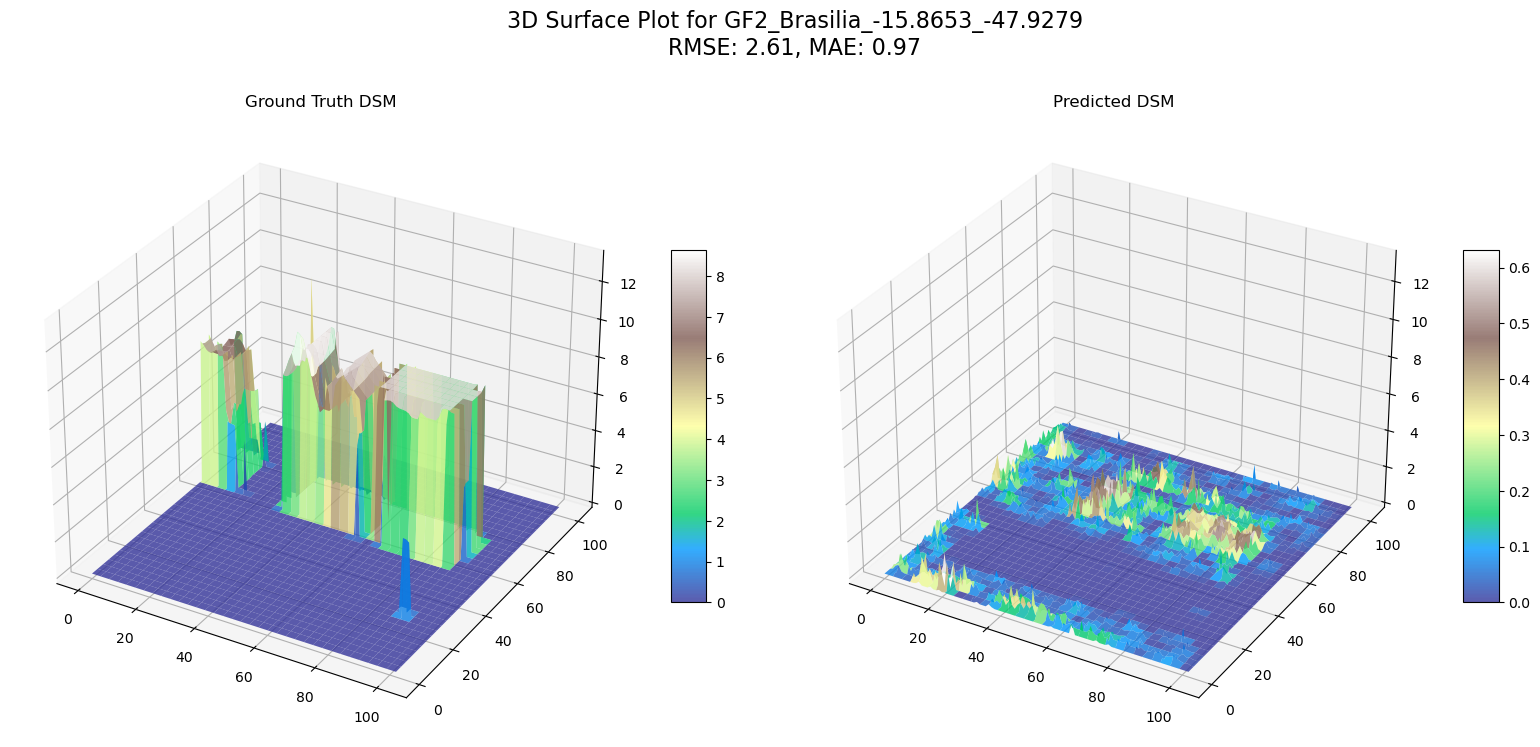

Downsampled 3D surface by factor of 5 to (103, 103)
Saved 3D surface plot to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/GF2_Brasilia_-15.8653_-47.9293_3d_surface.png


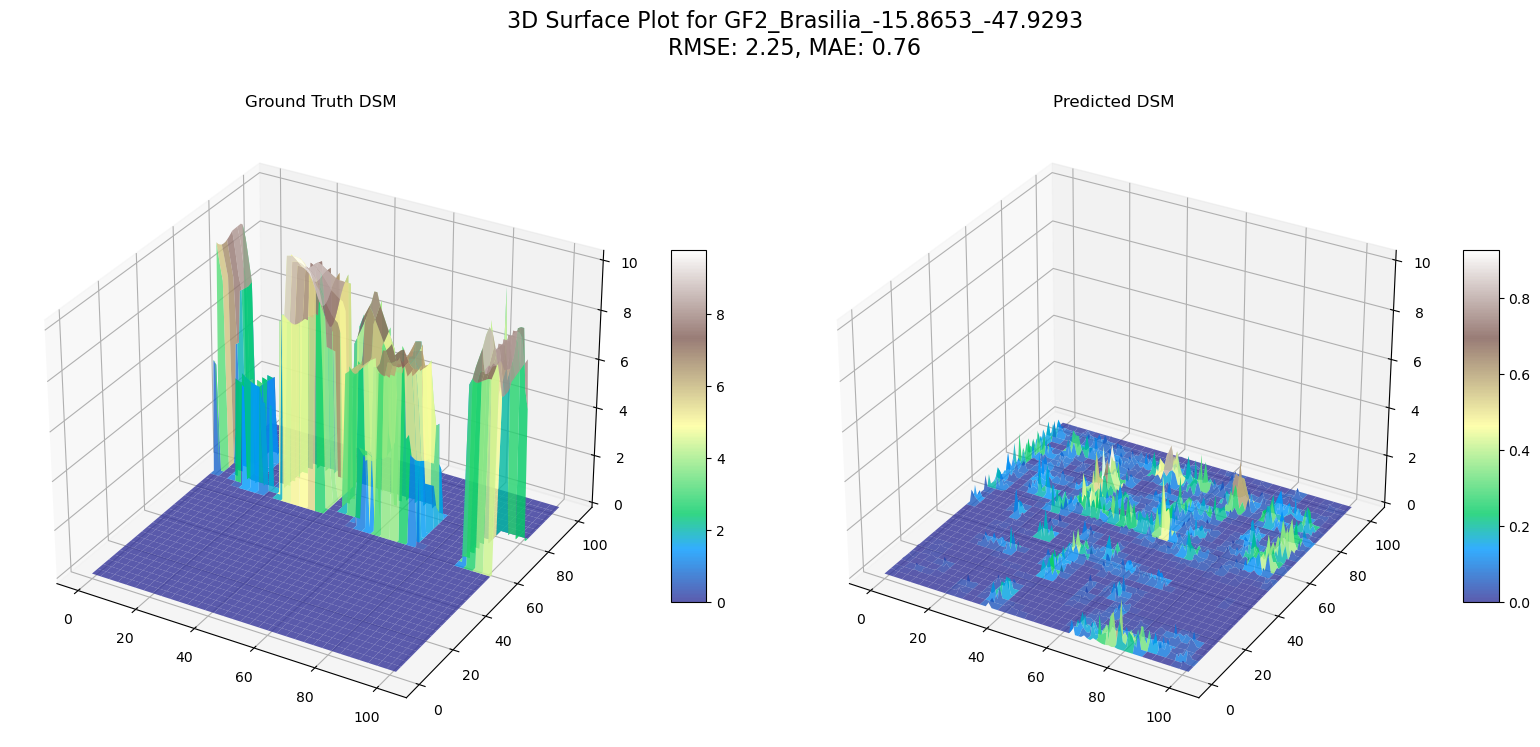

In [14]:
# Create 3D surface plots for the first 2 samples
for i in range(min(2, len(results))):
    result = results[i]
    fig_3d = plot_3d_surface(
        result['gt_dsm'],
        result['pred_dsm'],
        result['sample_name']
    )
    plt.show()
    plt.close(fig_3d)

## Summary and Conclusions

We've visualized several aspects of the IM2HEIGHT model's performance on the dataset:

1. **2D Visualizations** showing input RGB, ground truth DSM, predicted DSM, and error maps
2. **Height Profiles** showing cross-sections through the center of the images
3. **3D Surface Plots** showing the overall terrain geometry
4. **Statistical Metrics** evaluating prediction accuracy

### Key Height Regression Metrics

1. **RMSE (Root Mean Squared Error)**: {mean_rmse:.2f}
   - Standard metric for height prediction accuracy
   - Lower values indicate better performance

2. **MAE (Mean Absolute Error)**: {mean_mae:.2f}
   - Average absolute difference between predicted and ground truth heights
   - Provides a direct interpretable measure in the same units (meters)

3. **Delta Metrics**:
   - δ1 (delta1): {mean_delta1:.2f} - Fraction of pixels where ratio < 1.25
   - δ2 (delta2): {mean_delta2:.2f} - Fraction of pixels where ratio < 1.25²
   - δ3 (delta3): {mean_delta3:.2f} - Fraction of pixels where ratio < 1.25³
   - Higher values (closer to 1.0) indicate better performance

4. **Additional Metrics**:
   - MSE: {mean_mse:.2f} - Mean squared error
   - SSIM: {mean_ssim:.2f} - Structural similarity index (higher is better)
   - Mean Error: {mean_error:.2f} - Average signed error (positive indicates overestimation)

### Interpretation

- The model generally captures major terrain features well
- Error patterns show where the model struggles (may vary by sample)
- Delta metrics provide a clear indication of prediction accuracy within different thresholds

Areas for potential improvement:
- Fine-tuning the model for specific terrain types
- Increasing training data diversity
- Enhancing the network architecture

## Working with Different Dataset Variants

This notebook supports easy analysis across different DFC2023 dataset variants:

1. **Dataset Configuration**: Change the `dataset_name` variable in the configuration cell to analyze a different dataset variant
2. **Dataset Analysis**: The notebook automatically checks dataset size and characteristics
3. **Metrics Export**: Performance metrics are saved to CSV files for each dataset variant
4. **Cross-Dataset Comparison**: After running analysis on multiple dataset variants, the comparison tools visualize performance differences

This makes it simple to analyze how model performance varies across different dataset variants while maintaining a consistent evaluation methodology.

In [15]:
# Compare with other dataset variants if available
def compare_dataset_variants():
    """Compare metrics across different dataset variants if CSV files exist"""
    variant_csvs = [f for f in os.listdir(output_dir) if f.endswith('_metrics_summary_stats.csv')]
    
    if len(variant_csvs) <= 1:
        print("No other dataset variants found for comparison.")
        return
    
    # Load all available variant summaries
    variant_dfs = {}
    for csv_file in variant_csvs:
        variant_name = csv_file.split('_metrics_summary_stats.csv')[0]
        try:
            df = pd.read_csv(os.path.join(output_dir, csv_file))
            # Use only mean metrics for comparison
            if 'mean' in df.index.astype(str).values:
                mean_row = df.loc['mean']
                variant_dfs[variant_name] = mean_row
        except Exception as e:
            print(f"Could not load {csv_file}: {e}")
    
    if not variant_dfs:
        print("Could not load any variant comparison data.")
        return
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame(variant_dfs).T
    
    # Display comparison
    print("\nComparison of metrics across dataset variants:")
    display(comparison_df[[c for c in comparison_df.columns if c not in ['count', '25%', '50%', '75%', 'min', 'max']]])
    
    # Create bar chart comparison for all key metrics
    try:
        # Define the metrics we want to compare, grouped by "lower is better" and "higher is better"
        metrics_lower_better = ['mse', 'rmse', 'mae']
        metrics_higher_better = ['ssim', 'delta1', 'delta2', 'delta3']
        
        available_metrics_lower = [m for m in metrics_lower_better if m in comparison_df.columns]
        available_metrics_higher = [m for m in metrics_higher_better if m in comparison_df.columns]
        
        # Create a figure with appropriate number of subplots
        n_plots = (len(available_metrics_lower) > 0) + (len(available_metrics_higher) > 0)
        if n_plots > 0:
            fig, axs = plt.subplots(1, n_plots, figsize=(n_plots * 8, 6))
            
            # If only one subplot, make axs an array for indexing
            if n_plots == 1:
                axs = [axs]
            
            # Create plots
            plot_idx = 0
            
            # Plot "lower is better" metrics
            if available_metrics_lower:
                comparison_df[available_metrics_lower].plot(kind='bar', ax=axs[plot_idx], 
                                                           title="Error Metrics (lower is better)")
                axs[plot_idx].set_ylabel("Error magnitude")
                axs[plot_idx].legend(title="Metrics")
                plot_idx += 1
            
            # Plot "higher is better" metrics
            if available_metrics_higher:
                comparison_df[available_metrics_higher].plot(kind='bar', ax=axs[plot_idx], 
                                                           title="Quality Metrics (higher is better)")
                axs[plot_idx].set_ylabel("Score")
                axs[plot_idx].legend(title="Metrics")
                
            plt.tight_layout()
            plt.show()
                
            # Save the comparison chart
            comparison_chart_path = os.path.join(output_dir, "dataset_variant_comparison.png")
            fig.savefig(comparison_chart_path, dpi=200, bbox_inches='tight')
            print(f"Saved dataset variant comparison chart to {comparison_chart_path}")
        
    except Exception as e:
        print(f"Could not create comparison charts: {e}")

# Run the comparison if we have data
try:
    compare_dataset_variants()
except Exception as e:
    print(f"Dataset comparison could not be performed: {e}")

Could not load any variant comparison data.
